# 2 — Pipeline walkthrough

**Purpose:** run a single patient through every stage of the pipeline, one step at a time,
so the mechanics are visible rather than hidden inside `scripts/train.py`.

This notebook does not train anything. It uses an already-trained checkpoint to demonstrate
what each stage does to the data.

## Steps

| Step | Stage | Module |
|---|---|---|
| 1 | Load a cached patient | `src.data.load_case` |
| 2 | Normalise intensities | `src.preprocessing.normalize_volume` |
| 3 | Sample a training patch | `src.data.PatchDataset` |
| 4 | Build the network | `src.models.create_model` |
| 5 | One forward pass on a patch | — |
| 6 | Sliding-window inference on the full volume | `src.inference.sliding_window_inference` |
| 7 | Score the prediction | `src.metrics.evaluate_segmentation` |

**Prerequisites:** cache built, and at least one checkpoint present
(`python scripts/train.py --config nnunet_style`).

---
## Step 1 — Load a cached patient

`build_cache.py` has already done three things to this volume: cropped it to the brain
bounding box, remapped BraTS label 4 to 3 so the label set is contiguous, and stored it as
`float16` to halve disk and load time.

Note the shape — it is **not** the original `240×240×155`, because the empty space around the
brain has been removed. That crop discards roughly 60% of the voxels, all of them background.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.config import CACHE_DIR, PATCH_SIZE, NUM_CLASSES, CHECKPOINT_DIR, get_device
from src.data import cached_case_ids, load_case, split_cases

device = get_device()
_, _, test_ids = split_cases()
case_id = test_ids[0]

img, seg = load_case(case_id)

print(f"patient        : {case_id}  (held-out test set)")
print(f"image shape    : {img.shape}   (4 modalities, cropped to brain)")
print(f"label shape    : {seg.shape}")
print(f"original shape : (240, 240, 155)  ->  {100*(1 - np.prod(seg.shape)/(240*240*155)):.0f}% of voxels dropped by cropping")
print(f"labels present : {sorted(np.unique(seg).tolist())}   (4 was remapped to 3)")
print(f"device         : {device}")

patient        : BraTS2021_00583  (held-out test set)
image shape    : (4, 141, 193, 149)   (4 modalities, cropped to brain)
label shape    : (141, 193, 149)
original shape : (240, 240, 155)  ->  55% of voxels dropped by cropping
labels present : [0, 1, 2, 3]   (4 was remapped to 3)
device         : cuda


---
## Step 2 — Normalise intensities

Each modality is standardised independently, using statistics from **brain voxels only**.
Including the background zeros would drag the mean toward zero and shrink the standard
deviation, which would compress the actual tissue contrast into a narrow band.

Background stays exactly 0 after normalisation so it never contributes signal.

In [2]:
from src.preprocessing import normalize_volume

norm = normalize_volume(img, method="zscore")

print(f"{'modality':<10}{'raw mean':>12}{'raw std':>12}{'norm mean':>12}{'norm std':>12}")
for i, m in enumerate(["flair", "t1", "t1ce", "t2"]):
    raw_brain = img[i][img[i] > 0]
    norm_brain = norm[i][norm[i] != 0]
    print(f"{m:<10}{raw_brain.mean():>12.1f}{raw_brain.std():>12.1f}"
          f"{norm_brain.mean():>12.3f}{norm_brain.std():>12.3f}")

print(f"\nbackground after normalisation: {norm[0][img[0] == 0].max():.1f} (pinned to 0)")

modality      raw mean     raw std   norm mean    norm std
flair            284.8        97.0       0.000       1.000
t1               713.6       125.9      -0.000       1.000
t1ce             344.8       102.6       0.000       1.000
t2               427.8       186.5      -0.000       1.000

background after normalisation: 0.0 (pinned to 0)


---
## Step 3 — Sample a training patch

Training never sees a whole volume. A full `4×240×240×155` sample is ~142 MB in float32, and
the activations of a 3D U-Net over it do not fit in 8 GB of VRAM at any usable batch size.

Instead the model trains on `128³` patches. **Half of them are centred on a tumour voxel** —
without that bias, most random patches in a mostly-background volume would contain no tumour
at all, and a short training run would spend its budget learning to output zeros.

In [3]:
from src.data import PatchDataset

ds = PatchDataset([case_id], iterations=200, normalization="zscore", augment=False)

fg_fraction = []
for i in range(30):
    patch_img, patch_seg = ds[i]
    fg_fraction.append((patch_seg > 0).float().mean().item())

fg_fraction = np.array(fg_fraction)
print(f"patch shape          : {tuple(patch_img.shape)}")
print(f"patches sampled      : {len(fg_fraction)}")
print(f"patches with tumour  : {(fg_fraction > 0).sum()}/{len(fg_fraction)}")
print(f"mean tumour fraction : {fg_fraction.mean()*100:.1f}% of voxels per patch")
print(f"\nwhole-volume tumour fraction for comparison: {(seg > 0).mean()*100:.1f}%")
print("Foreground-biased sampling raises the tumour content the model actually sees.")

patch shape          : (4, 128, 128, 128)
patches sampled      : 30
patches with tumour  : 30/30
mean tumour fraction : 7.5% of voxels per patch

whole-volume tumour fraction for comparison: 3.9%
Foreground-biased sampling raises the tumour content the model actually sees.


---
## Step 4 — Build the network

A 3D U-Net: four downsampling stages, a bottleneck, four upsampling stages with skip
connections. Two details worth noting:

- **InstanceNorm rather than BatchNorm.** Batch size is 2 at this patch size, and BatchNorm
  statistics estimated from two samples are noise.
- **Deep supervision.** Auxiliary prediction heads on the two coarsest decoder levels give
  gradient signal directly to the deeper layers, which helps a short run converge faster.

In [4]:
from src.models import create_model, count_parameters

model = create_model("unet", num_classes=NUM_CLASSES, base_channels=16,
                     deep_supervision=True, device=str(device))

print(f"parameters       : {count_parameters(model)/1e6:.2f} M")
print(f"input channels   : 4  (one per modality)")
print(f"output channels  : {NUM_CLASSES}  (background + 3 tumour classes)")
print(f"downsamplings    : 4  -> input dims must be divisible by 16")
print(f"\n128 / 16 = {128//16}  ✓")
print(f"155 / 16 = {155/16:.2f}  ✗  <- why training uses patches, not whole volumes")

parameters       : 5.65 M
input channels   : 4  (one per modality)
output channels  : 4  (background + 3 tumour classes)
downsamplings    : 4  -> input dims must be divisible by 16

128 / 16 = 8  ✓
155 / 16 = 9.69  ✗  <- why training uses patches, not whole volumes


---
## Step 5 — One forward pass

With deep supervision the model returns a list: the full-resolution prediction first, then
the coarser auxiliary outputs. The loss weights these at 1.0 / 0.5 / 0.25 — the auxiliary
heads guide training but do not dominate it.

At inference only the first output is used.

In [5]:
patch_img, patch_seg = ds[0]
x = patch_img.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    outputs = model(x)

print(f"input  : {tuple(x.shape)}   (batch, modalities, H, W, D)")
print(f"\noutputs returned: {len(outputs)}")
for i, o in enumerate(outputs):
    role = "primary (used at inference)" if i == 0 else f"auxiliary, weight {[1.0, 0.5, 0.25][i]}"
    print(f"  [{i}] {tuple(o.shape)}   {role}")

pred_patch = outputs[0].argmax(1)[0].cpu().numpy()
print(f"\nargmax over class dim -> label map {pred_patch.shape}, "
      f"labels {sorted(np.unique(pred_patch).tolist())}")

input  : (1, 4, 128, 128, 128)   (batch, modalities, H, W, D)

outputs returned: 3
  [0] (1, 4, 128, 128, 128)   primary (used at inference)
  [1] (1, 4, 64, 64, 64)   auxiliary, weight 0.5
  [2] (1, 4, 32, 32, 32)   auxiliary, weight 0.25

argmax over class dim -> label map (128, 128, 128), labels [0, 1, 2, 3]


---
## Step 6 — Sliding-window inference on the full volume

The model was trained on `128³` patches but must predict a whole brain. Sliding-window
inference tiles the volume with 50% overlap and accumulates predictions.

Overlapping windows are blended with a **Gaussian weight** centred on each patch: voxels near
a patch border were predicted with less surrounding context and are less reliable, so they
contribute less. Flat averaging instead leaves visible grid seams at the patch boundaries.

This step loads a trained checkpoint. If none exists, run
`python scripts/train.py --config nnunet_style` first.

In [6]:
import time
from src.inference import predict_case

ckpt_path = CHECKPOINT_DIR / "nnunet_style_best.pt"

if not ckpt_path.exists():
    print(f"No checkpoint at {ckpt_path}")
    print("Run: python scripts/train.py --config nnunet_style")
    pred = None
else:
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    cfg = ckpt["settings"]
    trained = create_model(cfg["model"], num_classes=NUM_CLASSES,
                           base_channels=cfg["base_channels"],
                           deep_supervision=cfg["deep_supervision"], device=str(device))
    trained.load_state_dict(ckpt["model"])

    t0 = time.time()
    pred = predict_case(trained, img, normalization=cfg["normalization"], device=device)
    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.time() - t0

    print(f"checkpoint      : {ckpt_path.name}  (best val Dice {ckpt['val_mean_dice']:.4f} @ iter {ckpt['iter']})")
    print(f"prediction shape: {pred.shape}   (matches input, reassembled from patches)")
    print(f"labels predicted: {sorted(np.unique(pred).tolist())}")
    print(f"inference time  : {elapsed:.2f} s")

checkpoint      : nnunet_style_best.pt  (best val Dice 0.8565 @ iter 2000)
prediction shape: (141, 193, 149)   (matches input, reassembled from patches)
labels predicted: [0, 1, 2, 3]
inference time  : 1.10 s


---
## Step 7 — Score the prediction

BraTS is **not** scored per label. It is scored on three nested regions, and the evaluation
here follows that convention exactly:

- **WT** (whole tumour) = labels 1 + 2 + 3
- **TC** (tumour core) = labels 1 + 3 — the tumour without surrounding oedema
- **ET** (enhancing tumour) = label 3 only

Two metrics per region. **Dice** measures overlap — how much of the region was found.
**HD95** measures the 95th-percentile surface distance — how far off the boundary is at its
worst. They answer different questions: a prediction can have good overlap but a ragged
boundary, and only HD95 will show it.

BraTS2021_00583  (held-out test patient)

region      Dice     HD95    sens    spec
WT         0.959      2.8   0.938   0.999
TC         0.923      3.7   0.878   1.000
ET         0.873      2.8   0.824   0.999


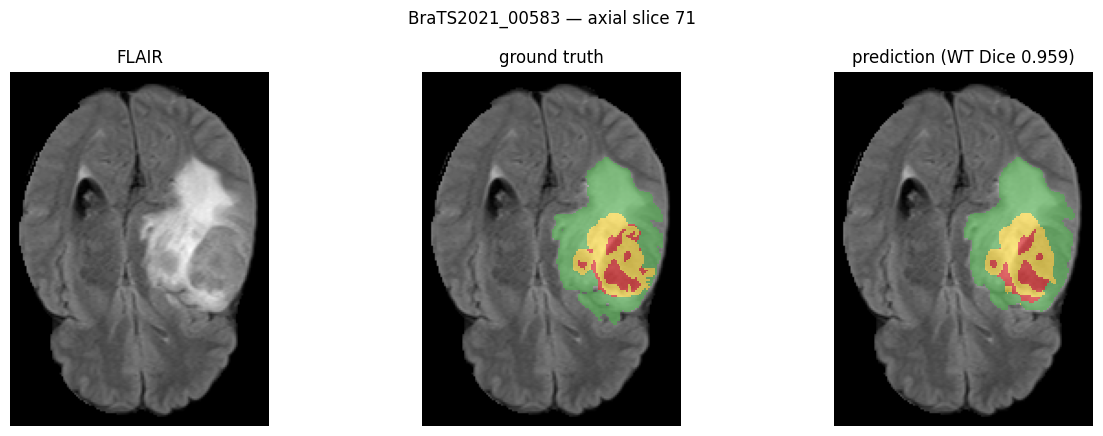

In [7]:
from src.metrics import evaluate_segmentation

if pred is None:
    print("No prediction to score - train a model first.")
else:
    results = evaluate_segmentation(pred, seg)

    print(f"{case_id}  (held-out test patient)\n")
    print(f"{'region':<8}{'Dice':>8}{'HD95':>9}{'sens':>8}{'spec':>8}")
    for region, m in results.items():
        print(f"{region:<8}{m['dice']:>8.3f}{m['hd95']:>9.1f}{m['sensitivity']:>8.3f}{m['specificity']:>8.3f}")

    # Visual comparison on the busiest slice.
    z = int((seg > 0).sum(axis=(0, 1)).argmax())
    from matplotlib.colors import ListedColormap
    cmap = ListedColormap(["#e41a1c", "#4daf4a", "#ffd92f"])

    fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
    axes[0].imshow(np.rot90(img[0][:, :, z]), cmap="gray")
    axes[0].set_title("FLAIR")
    for ax, data, title in [(axes[1], seg, "ground truth"),
                            (axes[2], pred, f"prediction (WT Dice {results['WT']['dice']:.3f})")]:
        ax.imshow(np.rot90(img[0][:, :, z]), cmap="gray")
        ax.imshow(np.ma.masked_equal(np.rot90(data[:, :, z]), 0), cmap=cmap,
                  vmin=1, vmax=3, alpha=0.6, interpolation="nearest")
        ax.set_title(title)
    for ax in axes:
        ax.axis("off")
    fig.suptitle(f"{case_id} — axial slice {z}")
    fig.tight_layout()
    plt.show()

---
## What this walkthrough showed

One patient, seven stages, each one a function that `scripts/train.py` and
`scripts/evaluate.py` call in exactly the same way. Nothing here is notebook-only code — the
notebook is a viewer over the same modules the pipeline runs.

That is the practical difference between a notebook and a pipeline: this file could be
deleted without affecting whether the project runs.

**Next:** `03_results.ipynb` covers the measured results across all three configurations.